In [24]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
from matplotlib.lines import Line2D
from pathlib import Path
import numpy as np
import warnings
warnings.filterwarnings("ignore")
np.seterr(all="ignore")
pd.options.mode.chained_assignment = None

# ---- config (edit freely) -------------------------------------------------
DATA = Path("data/20250710_0000-20260729_0000.parquet")
END   = "2025-10-01"         # analyse only up to this date (exclusive)
START = None                 # e.g. "2025-07-10", or None for "from the start"

TARGET = "TMS_nox"

BURNERS = [f"{i}{s}" for s in ("L", "R") for i in (1, 2, 3, 4)]
INCLUDE_0R = False           # there is a 0R burner with no L counterpart
if INCLUDE_0R:
    BURNERS.append("0R")

USE_CLEANED_OIL = True      # False -> raw "OIL 1L", True -> "OIL 1L_cleaned"
OIL_SUFFIX = "_cleaned" if USE_CLEANED_OIL else ""

OTHER = [
    "ARCH #3",
    "MELTER BT #11",
    "GLASS LEVEL [mm]",
    "FURNACE PRESSURE [mmAq]",
    "WEATHER_temp",
    "WEATHER_acc_precip",
    "WEATHER_humi",
]

# NOx reads 0 on a regular ~4h cycle (analyser zero/calibration) -> repaired copy
NOX_MIN_VALID = 10.0          # readings <= this anchor a dropout
NOX_DROP_FRAC = 0.6          # ...and it extends while NOx < this * the local level
NOX_REF_WIN   = "2h"         # window the "local level" median is taken over
NOX_PAD       = "2min"       # widen each dropout both ways (eats the ramp)
NOX_FILL      = "interp"     # "interp" = straight line across the gap, "ffill" = hold
NOX_FFILL_MAX = "10min"      # longest dropout we're willing to bridge (None = any)
# ---------------------------------------------------------------------------

OXY_COLS  = [f"OXY {b}" for b in BURNERS]
OIL_COLS  = [f"OIL {b}{OIL_SUFFIX}" for b in BURNERS]
OXY_MAIN  = "OXY MAIN"
OIL_MAIN  = f"OIL MAIN{OIL_SUFFIX}"
# every main variant, so no later cell has to re-open the file
MAIN_COLS = ["OXY MAIN", "OXY MAIN_cleaned", "OIL MAIN", "OIL MAIN_cleaned"]
TARGET_FFILL = f"{TARGET}_ffill"

# one read, one pass: keep only what the file actually has
want = list(dict.fromkeys(["Date", TARGET] + OXY_COLS + OIL_COLS + MAIN_COLS + OTHER))
have = set(pq.ParquetFile(DATA).schema_arrow.names)
cols = [c for c in want if c in have]
if len(cols) < len(want):
    print("not in file, skipped:", [c for c in want if c not in have])

df = pd.read_parquet(DATA, columns=cols)
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()

if START:
    df = df.loc[START:]
df = df.loc[df.index < END]

MAIN_COLS = [c for c in MAIN_COLS if c in df.columns]
FLOW_COLS = OXY_COLS + OIL_COLS + MAIN_COLS

# physically impossible readings -> NaN
df[FLOW_COLS] = df[FLOW_COLS].where(df[FLOW_COLS] > 0)

# per-burner oxy/oil ratio (+ the MAIN ratio the plot cell marks jumps on)
for b in BURNERS:
    df[f"RATIO {b}"] = df[f"OXY {b}"] / df[f"OIL {b}{OIL_SUFFIX}"]
if OXY_MAIN in df.columns and OIL_MAIN in df.columns:
    df["RATIO MAIN"] = df[OXY_MAIN] / df[OIL_MAIN]
else:
    print("!! no MAIN ratio — missing", [c for c in (OXY_MAIN, OIL_MAIN) if c not in df.columns])

# ---- NOx dropout repair ---------------------------------------------------
step = df.index.to_series().diff().median()
raw  = df[TARGET]

zero = raw.isna() | (raw <= NOX_MIN_VALID)                 # the hard anchor
ref  = raw.mask(zero).rolling(NOX_REF_WIN, center=True, min_periods=10).median()
low  = raw.lt(NOX_DROP_FRAC * ref) | zero                  # the ramp down/up too

grp     = (low != low.shift()).cumsum()                    # contiguous low runs
nox_bad = low & zero.groupby(grp).transform("any")         # keep runs holding a zero

k_pad = int(round(pd.Timedelta(NOX_PAD) / step)) if NOX_PAD else 0
if k_pad:                                                  # grow each run both ways
    nox_bad = (nox_bad.rolling(2 * k_pad + 1, center=True, min_periods=1)
                      .max().astype(bool))

_lim = None if not NOX_FFILL_MAX else max(1, int(round(pd.Timedelta(NOX_FFILL_MAX) / step)))
_s = raw.mask(nox_bad)
df[TARGET_FFILL] = (_s.interpolate("time", limit=_lim, limit_area="inside")
                    if NOX_FILL == "interp" else _s.ffill(limit=_lim))
df["nox_filled"] = nox_bad                                 # for the plot shading

_starts = df.index[(nox_bad & ~nox_bad.shift(1, fill_value=False)).to_numpy()]
_ends   = df.index[(nox_bad & ~nox_bad.shift(-1, fill_value=False)).to_numpy()]
if len(_starts):
    _len  = (_ends - _starts) + step
    _gap  = _starts.to_series().diff()
    _fill = df.loc[nox_bad, TARGET_FFILL]
    print(f"NOx dropouts: {len(_starts)} events / {int(nox_bad.sum())} samples "
          f"({nox_bad.mean():.2%}) | median length {_len.median()} "
          f"| median spacing {_gap.median()}")
    print(f"  masked raw range {raw[nox_bad].min():.1f}..{raw[nox_bad].max():.1f} "
          f"-> filled with {_fill.min():.1f}..{_fill.max():.1f} "
          f"(local level ~{ref.median():.1f})")
    print(f"  -> '{TARGET_FFILL}': {int(df[TARGET_FFILL].isna().sum())} still NaN")
else:
    print("no NOx dropouts found — check NOX_MIN_VALID")

RATIO_COLS = [f"RATIO {b}" for b in BURNERS]
FEATURES = FLOW_COLS + RATIO_COLS + OTHER

assert {TARGET_FFILL, "nox_filled"} <= set(df.columns)
print(df.shape, "| interval:", step, "| added:", TARGET_FFILL, "nox_filled", "RATIO MAIN")
print(df.index.min(), "->", df.index.max())
df[RATIO_COLS].describe().T


not in file, skipped: ['OXY MAIN_cleaned']
NOx dropouts: 399 events / 10690 samples (5.68%) | median length 0 days 00:07:00 | median spacing 0 days 04:00:00
  masked raw range 0.0..546.0 -> filled with 57.1..419.9 (local level ~134.5)
  -> 'TMS_nox_ffill': 4837 still NaN
(188140, 38) | interval: 0 days 00:00:30 | added: TMS_nox_ffill nox_filled RATIO MAIN
2025-07-10 00:00:00 -> 2025-09-30 23:59:30


,count,mean,std,min,25%,50%,75%,max
RATIO 1L,179695.0,1.951227,0.053986,0.014518,1.914634,1.956731,1.996675,3.458582
RATIO 2L,188140.0,1.950336,0.052067,0.123412,1.914381,1.955075,1.997600,3.218693
RATIO 3L,188140.0,1.943205,0.049437,0.044627,1.911887,1.952132,1.986486,2.369491
RATIO 4L,188140.0,1.947655,0.060277,0.349349,1.908066,1.950476,1.995017,4.731732
RATIO 1R,188140.0,1.949447,0.053846,1.665079,1.913476,1.955272,1.996678,2.480119
RATIO 2R,188140.0,1.950852,0.054255,0.014159,1.914605,1.955038,1.997691,3.601770
RATIO 3R,188140.0,1.943229,0.057571,0.242974,1.910000,1.950091,1.987749,3.122715
RATIO 4R,188136.0,1.945702,0.053371,0.005000,1.905079,1.942559,1.986351,3.291000


In [25]:
# ---- available start windows ----------------------------------------------
WIN_LEN = "6h"      # same value you'll use in the plot cell
TOP     = None      # None = list all; or e.g. 20 to see only the widest-range ones
SORT_BY = "nox_range"   # "nox_range", "ratio_range", or "start"
# ---------------------------------------------------------------------------

gr  = pd.Grouper(freq=WIN_LEN)
idx = df.index.to_series()
rat = df[RATIO_COLS]

nox_min, nox_max = df[TARGET].groupby(gr).min(), df[TARGET].groupby(gr).max()
rat_min = rat.min(axis=1).groupby(gr).min()
rat_max = rat.max(axis=1).groupby(gr).max()

avail = pd.DataFrame({
    "start":     idx.groupby(gr).min(),
    "end":       idx.groupby(gr).max(),
    "samples":   idx.groupby(gr).size(),
    "nox_min":   nox_min.round(1),
    "nox_max":   nox_max.round(1),
    "nox_range": (nox_max - nox_min).round(1),
    "ratio_min": rat_min.round(3),
    "ratio_max": rat_max.round(3),
    "ratio_range": (rat_max - rat_min).round(3),
})
avail = avail[avail["samples"] > 0]

print(f"data: {df.index.min()} -> {df.index.max()}   |   {len(avail)} windows of {WIN_LEN}\n")

view = avail if SORT_BY == "start" else avail.sort_values(SORT_BY, ascending=False)
with pd.option_context("display.max_rows", 200, "display.width", 220):
    print((view.head(TOP) if TOP else view).to_string())


data: 2025-07-10 00:00:00 -> 2025-09-30 23:59:30   |   271 windows of 6h

                                  start                 end  samples  nox_min  nox_max  nox_range  ratio_min  ratio_max  ratio_range
Date                                                                                                                                
2025-09-26 06:00:00 2025-09-26 06:00:00 2025-09-26 11:59:30      720      0.0    546.0      546.0      1.860      1.991        0.130
2025-08-01 06:00:00 2025-08-01 06:00:00 2025-08-01 11:59:30      720      0.0    511.0      511.0      1.818      2.235        0.417
2025-09-12 06:00:00 2025-09-12 06:00:00 2025-09-12 11:59:30      719      0.0    499.0      499.0      1.800      2.320        0.520
2025-07-18 06:00:00 2025-07-18 06:00:00 2025-07-18 11:59:30      720      0.0    468.0      468.0      1.952      2.173        0.221
2025-08-29 06:00:00 2025-08-29 06:00:00 2025-08-29 11:59:30      720      0.0    461.0      461.0      1.860      2.214        0

In [219]:
# ---- config ---------------------------------------------------------------
WIN_START = "2025-09-11 06:00:00"
WIN_LEN   = "6h"                 # min "1h", max "1D"

PANELS = [["1L", "1R"], ["2L", "2R"], ["3L", "3R"], ["4L", "4R"], ["0R"]]
SHARE_RATIO_Y = True             # applies to the burner panels

NOX_SERIES    = "raw"          # "raw" = TMS_nox, "ffill" = dropout-repaired copy
SHOW_NOX_FILL = True             # shade the stretches that were filled in

NOX_LIMIT  = 180
NOX_NORMAL = (120, 130)

# ---- jumps: NOx from NOx, ratio from the MAIN oxy/oil ratio only ----------
MARK_JUMPS = True

# mode: "abs" = fixed threshold, "mad" = adaptive, "both" = fire if either does
NOX_MODE    = "mad"
NOX_JUMP    = 20.0        # abs: |change| over LOOKBACK
NOX_MAD_WIN = "20min"     # trailing window the MAD scale is measured over
NOX_MAD_K   = 4.0         # fire above this many sigma-equivalents
NOX_MAD_CAP = 10.0        # ...but reject above this many (implausible). None = no cap
NOX_MAD_MIN = 1.0         # floor on the scale, so a flat window isn't hair-trigger

RATIO_MODE    = "mad"
RATIO_JUMP    = 0.07
RATIO_MAD_WIN = "20min"
RATIO_MAD_K   = 3.0
RATIO_MAD_CAP = 30.0
RATIO_MAD_MIN = 0.01

LOOKBACK   = "5min"      # span the change is measured over
MERGE_GAP  = "7min"       # hits closer than this are one event
MAX_MARKS  = 20           # cap on MAIN marks, keeps the most significant
MARK_AT    = "first"       # "first" = earliest crossing, "peak" = largest change

EXPLAIN_MARKS = True      # print every candidate jump and why it was kept/dropped



# ---- lag: earliest MAIN takes the earliest NOx after it, each NOx used once
SHOW_LAG = True
MAX_LAG  = "30min"        # ignore a NOx jump further away than this

# ---- layout / output ------------------------------------------------------
FIG_W, ROW_H = 18, 2.6

SAVE     = True
SAVE_DIR = Path("pres")
DPI      = 150
EXPLAIN_MARKS = True      # print every candidate jump and why it was kept/dropped


NOX_C      = "#3e58ad"
SIDE_COLOR = {"L": "#4a9cff", "R": "#5fdb4a"}
COMBO_C    = "#ff8317fc"
MAINR_C    = "#6A5347"

LIMIT_C    = "#e34948"
BAND_C     = "#47806c"
GRID_C     = "#d8d8d4"
NOXMARK_C  = "#ff2374"
RATMARK_C  = "#7c30ff"
FILL_C     = "#b0b0b0"
LAG_C      = "#564d50"
# ---------------------------------------------------------------------------


2025-09-11 06:00:00 -> 2025-09-11 12:00:00   721 samples
NOx series: TMS_nox  (30 dropout samples in this window)
skipped (not loaded in cell 1): ['0R']
  NOx: median scale 4.0771 -> fire above 16.3086, reject above 40.7715
  NOx 07:27:00  abs  --  mad 81/11.86=6.83x  peak=128 (43.2·MAD)  fired=mad  -> dropped: peak over the 10.0·MAD cap
  NOx 07:34:00  abs  --  mad 128/11.86=10.79x  peak=128 (43.2·MAD)  fired=mad  -> dropped: peak over the 10.0·MAD cap
  NOx 09:24:00  abs  --  mad 22/20.76=1.06x  peak=22 (4.2·MAD)  fired=mad  -> kept
  NOx 10:17:00  abs  --  mad 21/20.76=1.01x  peak=27 (5.2·MAD)  fired=mad  -> kept
  NOx 10:51:30  abs  --  mad 12/11.86=1.01x  peak=31 (10.5·MAD)  fired=mad  -> dropped: peak over the 10.0·MAD cap
  NOx 10:58:30  abs  --  mad 21/16.31=1.29x  peak=37 (9.1·MAD)  fired=mad  -> kept
  NOx 11:27:00  abs  --  mad 92/29.65=3.10x  peak=140 (18.9·MAD)  fired=mad  -> dropped: peak over the 10.0·MAD cap
  NOx 11:34:00  abs  --  mad 135/29.65=4.55x  peak=135 (18.2·M

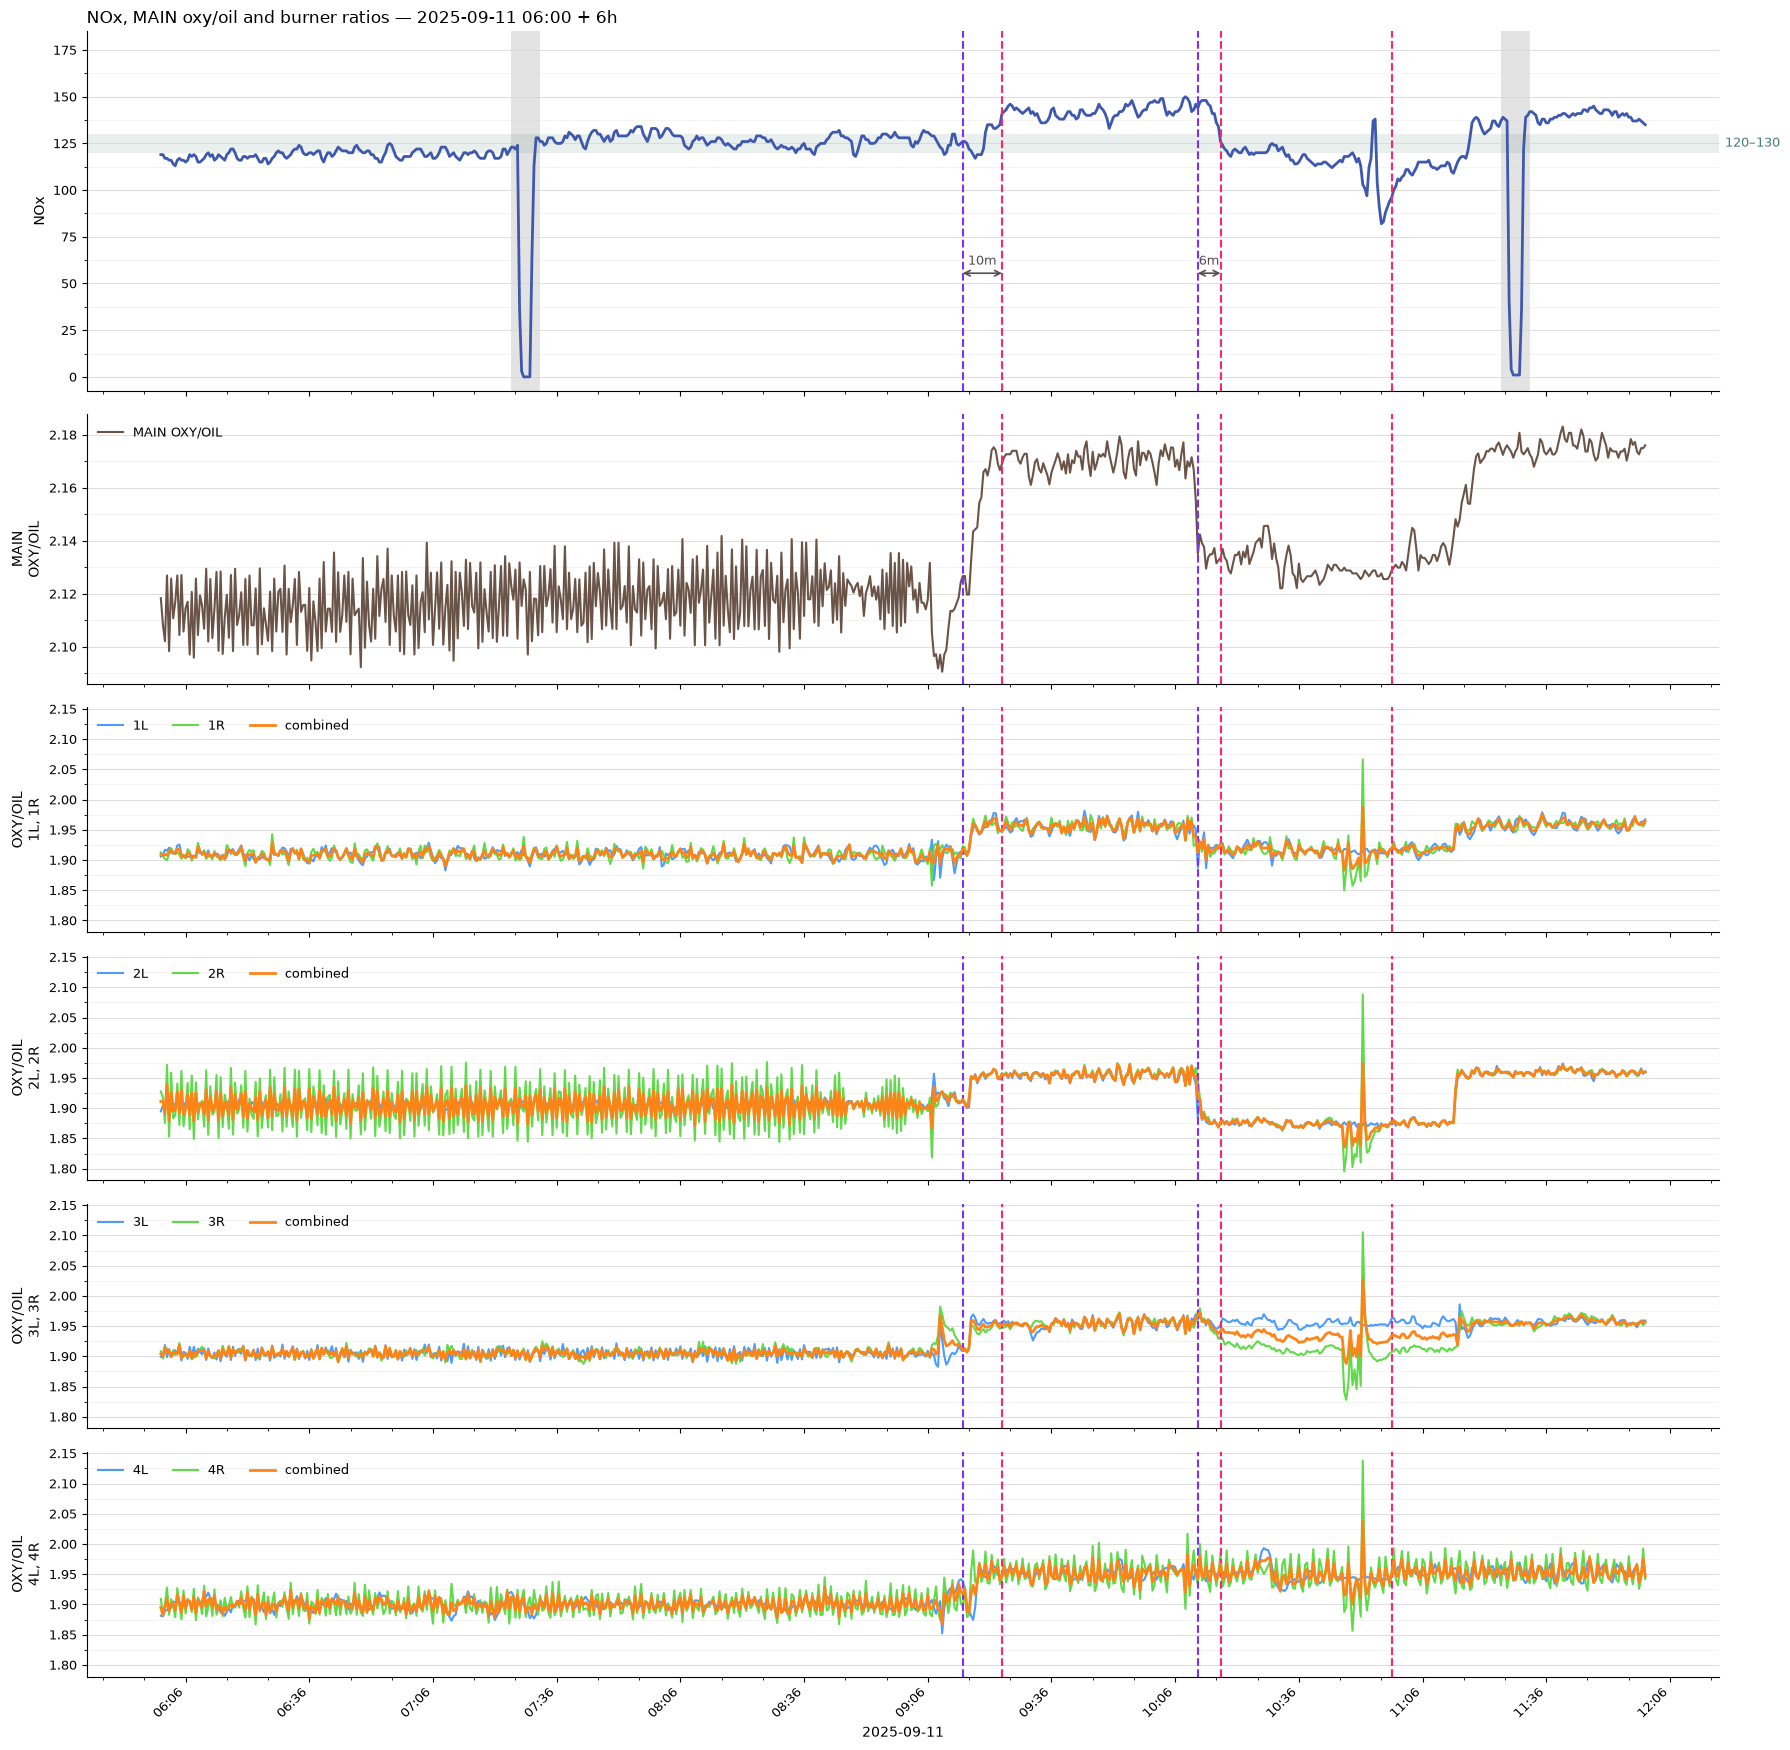

In [220]:

_lo, _hi = pd.Timedelta("1h"), pd.Timedelta("1D")
assert _lo <= pd.Timedelta(WIN_LEN) <= _hi, f"WIN_LEN must be 1h..1D, got {WIN_LEN}"

t0 = pd.Timestamp(WIN_START)
t1 = t0 + pd.Timedelta(WIN_LEN)
w = df.loc[t0:t1]
print(f"{t0} -> {t1}   {len(w)} samples")

NOX_COL = TARGET_FFILL if NOX_SERIES == "ffill" else TARGET
nox     = w[NOX_COL]
filled  = w["nox_filled"]
print(f"NOx series: {NOX_COL}  ({int(filled.sum())} dropout samples in this window)")

panels = [[b for b in p if f"RATIO {b}" in w] for p in PANELS]
panels = [p for p in panels if p]
missing = {b for p in PANELS for b in p} - {b for p in panels for b in p}
if missing:
    print("skipped (not loaded in cell 1):", sorted(missing))

ratio_main = w["RATIO MAIN"]

combined = {}
for burners in panels:
    oxy = w[[f"OXY {b}" for b in burners]].sum(axis=1, min_count=1)
    oil = w[[f"OIL {b}{OIL_SUFFIX}" for b in burners]].sum(axis=1, min_count=1)
    combined["+".join(burners)] = oxy / oil
combined = pd.DataFrame(combined, index=w.index)

# ---- jump detection -------------------------------------------------------
def jump_times(s, mode, abs_thr, mad_win, k_mad, k_cap, floor,
               max_marks=None, name=""):
    """|change over LOOKBACK| past a fixed threshold, k_mad * trailing MAD, or either —
    rejected again above k_cap * trailing MAD."""
    step = w.index.to_series().diff().median()
    k = max(1, int(round(pd.Timedelta(LOOKBACK) / step)))
    d = s.diff(k).abs()

    n     = max(2, int(round(pd.Timedelta(mad_win) / step)))
    ch    = s.diff(k)
    med   = ch.rolling(n, min_periods=n // 4).median()
    mad   = (ch - med).abs().rolling(n, min_periods=n // 4).median()
    sigma = (1.4826 * mad).clip(lower=floor).shift(k)   # PRECEDING window
    thr_mad = sigma * k_mad
    thr_cap = sigma * k_cap if k_cap else None

    hit = pd.Series(False, index=s.index)
    if mode in ("abs", "both"):
        hit |= d.gt(abs_thr).fillna(False)
    if mode in ("mad", "both"):
        hit |= d.gt(thr_mad).fillna(False)
    print(f"  {name}: median scale {sigma.median():.4f} -> fire above "
          f"{thr_mad.median():.4f}" +
          (f", reject above {thr_cap.median():.4f}" if thr_cap is not None else ""))

    t = d.index[hit.to_numpy()]
    if len(t) == 0:
        print(f"  {name}: no hits")
        return pd.DatetimeIndex([])

    keep = [t[0]]                                # merge hits into events
    for x in t[1:]:
        if x - keep[-1] >= pd.Timedelta(MERGE_GAP):
            keep.append(x)
    keep = pd.DatetimeIndex(keep)

    gap = pd.Timedelta(MERGE_GAP)
    if MARK_AT == "peak":
        keep = pd.DatetimeIndex([d.loc[m:m + gap].idxmax() for m in keep])

    # ---- per-event bookkeeping --------------------------------------------
    rows = []
    for m in keep:
        peak  = d.loc[m:m + gap].max()           # the cap judges the whole event
        r_abs = d[m] / abs_thr if mode in ("abs", "both") else np.nan
        r_mad = d[m] / thr_mad[m] if mode in ("mad", "both") else np.nan
        why = "+".join([x for x, r in (("abs", r_abs), ("mad", r_mad))
                        if r == r and r > 1])
        rows.append({"t": m, "d": d[m], "peak": peak, "r_abs": r_abs, "r_mad": r_mad,
                     "thr_mad": thr_mad[m], "sig": peak / sigma[m],
                     "why": why, "score": np.nanmax([r_abs, r_mad]), "status": "kept"})
    info = pd.DataFrame(rows).set_index("t")

    if thr_cap is not None:                      # implausibly large -> reject
        over = info["peak"] > thr_cap.reindex(info.index)
        info.loc[over.fillna(False), "status"] = (
            f"dropped: peak over the {k_cap}·MAD cap")

    ok = info[info["status"] == "kept"]
    if max_marks and len(ok) > max_marks:        # keep the most significant
        cut = ok["score"].nsmallest(len(ok) - max_marks).index
        info.loc[cut, "status"] = f"dropped: outside the top {max_marks} by score"

    if EXPLAIN_MARKS:
        for m, r in info.iterrows():
            a  = f"abs {r.d:.4g}/{abs_thr:g}={r.r_abs:.2f}x" if r.r_abs == r.r_abs else "abs  --"
            mm = (f"mad {r.d:.4g}/{r.thr_mad:.4g}={r.r_mad:.2f}x"
                  if r.r_mad == r.r_mad else "mad  --")
            print(f"  {name} {m:%H:%M:%S}  {a}  {mm}  peak={r.peak:.4g} "
                  f"({r.sig:.1f}·MAD)  fired={r.why or '-'}  -> {r.status}")

    keep = info.index[info["status"] == "kept"]
    print(f"  {name}: {len(keep)} marks kept of {len(info)} events ({len(t)} raw hits)")
    return pd.DatetimeIndex(keep)


nox_marks = rat_marks = pd.DatetimeIndex([])
if MARK_JUMPS:
    nox_marks = jump_times(nox, NOX_MODE, NOX_JUMP, NOX_MAD_WIN, NOX_MAD_K,
                           NOX_MAD_CAP, NOX_MAD_MIN, None, "NOx")
    rat_marks = jump_times(ratio_main, RATIO_MODE, RATIO_JUMP, RATIO_MAD_WIN,
                           RATIO_MAD_K, RATIO_MAD_CAP, RATIO_MAD_MIN,
                           MAX_MARKS, "MAIN")
    print(f"jumps: NOx ({NOX_MODE}) {len(nox_marks)} | "
          f"MAIN ratio ({RATIO_MODE}) {len(rat_marks)}")



# ---- figure ---------------------------------------------------------------
n = 2 + len(panels)              # NOx, MAIN ratio, burner panels
fig, axes = plt.subplots(n, 1, figsize=(FIG_W, 2 + ROW_H * n), sharex=True,
                         gridspec_kw={"height_ratios": [1.6, 1.2] + [1] * len(panels)})

ax0, ax_mr = axes[0], axes[1]
ratio_axes = list(axes[2:])

# NOx
ax0.axhspan(*NOX_NORMAL, color=BAND_C, alpha=0.12, lw=0)
ax0.plot(w.index, nox, lw=2, color=NOX_C)
ax0.set_ylabel("NOx" + (f" ({NOX_FILL})" if NOX_SERIES == "ffill" else ""))
ax0.set_title(f"NOx, MAIN oxy/oil and burner ratios — {t0:%Y-%m-%d %H:%M} + {WIN_LEN}", loc="left")
ax0.annotate(f"{NOX_NORMAL[0]}–{NOX_NORMAL[1]}", xy=(1, sum(NOX_NORMAL) / 2),
             xycoords=("axes fraction", "data"), xytext=(4, 0), textcoords="offset points",
             va="center", color=BAND_C, fontsize=9)

# shade the dropout stretches that were filled in
if SHOW_NOX_FILL and filled.any():
    f = filled.to_numpy()
    s_i = np.flatnonzero(f & ~np.r_[False, f[:-1]])
    e_i = np.flatnonzero(f & ~np.r_[f[1:], False])
    for a, b in zip(w.index[s_i], w.index[e_i]):
        ax0.axvspan(a, b, color=FILL_C, alpha=0.35, lw=0, zorder=0)

lo, hi = ax0.get_ylim()
ax0.set_ylim(min(lo, NOX_NORMAL[0] - 5), max(hi, NOX_LIMIT + 5))

n_over = int((nox > NOX_LIMIT).sum())
if n_over:
    print(f"!! {n_over} samples above the {NOX_LIMIT} limit in this window")

# MAIN ratio -- the jump source
ax_mr.plot(w.index, ratio_main, lw=1.5, color=MAINR_C, label="MAIN OXY/OIL")
ax_mr.set_ylabel("MAIN\nOXY/OIL")
ax_mr.legend(ncol=1, frameon=False, loc="upper left", fontsize=9)

# burner panels
for ax, burners in zip(ratio_axes, panels):
    for b in burners:
        ax.plot(w.index, w[f"RATIO {b}"], lw=1.5, color=SIDE_COLOR[b[-1]], label=b)
    if len(burners) > 1:
        ax.plot(w.index, combined["+".join(burners)], lw=2,
                color=COMBO_C, label="combined", zorder=4)
    ax.set_ylabel("OXY/OIL\n" + ", ".join(burners))
    ax.legend(ncol=3, frameon=False, loc="upper left", fontsize=9)

if SHARE_RATIO_Y:
    lim = (min(a.get_ylim()[0] for a in ratio_axes), max(a.get_ylim()[1] for a in ratio_axes))
    for ax in ratio_axes:
        ax.set_ylim(lim)

# ---- vertical jump markers, across every panel ----------------------------
for ax in axes:
    for t in rat_marks:
        ax.axvline(t, color=RATMARK_C, lw=1.5, ls="--")
    for t in nox_marks:
        ax.axvline(t, color=NOXMARK_C, lw=1.5, ls="--")

# ---- lag from MAIN-ratio jump to the following NOx jump -------------------
# earliest MAIN takes the earliest NOx after it; each NOx is used at most once
lags = []
if SHOW_LAG and len(rat_marks) and len(nox_marks):
    free = list(pd.DatetimeIndex(nox_marks).sort_values())    # unpaired NOx jumps
    for tr in pd.DatetimeIndex(rat_marks).sort_values():
        nxt = next((i for i, tn in enumerate(free)
                    if tn > tr and tn - tr <= pd.Timedelta(MAX_LAG)), None)
        if nxt is None:
            continue
        tn = free.pop(nxt)
        lags.append((tr, tn, tn - tr))

    y = ax0.get_ylim()[1]
    for tr, tn, dt in lags:
        ax0.annotate("", xy=(tn, y * 0.3), xytext=(tr, y * 0.3),
                     arrowprops=dict(arrowstyle="<->", color=LAG_C, lw=1.2,
                                     shrinkA=0, shrinkB=0))
        ax0.annotate(f"{dt.total_seconds() / 60:.0f}m",
                     xy=(tr + dt / 2, y * 0.3), xytext=(0, 4),
                     textcoords="offset points", ha="center", va="bottom",
                     color=LAG_C, fontsize=9)

    d = pd.Series([l[2] for l in lags])
    print(f"\nratio->NOx lag: n={len(d)}  median={d.median()}  "
          f"min={d.min()}  max={d.max()}  "
          f"({len(rat_marks) - len(lags)} MAIN unpaired, {len(free)} NOx unpaired)")
    for tr, tn, dt in lags:
        print(f"  {tr:%H:%M:%S} -> {tn:%H:%M:%S}   {dt}")

# ---- axes / grid ----------------------------------------------------------
for ax in axes:
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8, steps=[1, 2, 2.5, 5, 10]))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(axis="y", which="major", lw=0.6, color=GRID_C)
    ax.grid(axis="y", which="minor", lw=0.4, color=GRID_C, alpha=0.5)
    ax.grid(axis="x", visible=False, which="both")
    ax.tick_params(which="both", labelsize=9)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

span_h = pd.Timedelta(WIN_LEN) / pd.Timedelta("1h")
if span_h <= 2:     maj, mnr, fmt = mdates.MinuteLocator(interval=10), mdates.MinuteLocator(interval=2),  "%H:%M"
elif span_h <= 6:   maj, mnr, fmt = mdates.MinuteLocator(interval=30), mdates.MinuteLocator(interval=10), "%H:%M"
elif span_h <= 12:  maj, mnr, fmt = mdates.HourLocator(interval=1),    mdates.MinuteLocator(interval=15), "%H:%M"
else:               maj, mnr, fmt = mdates.HourLocator(interval=2),    mdates.MinuteLocator(interval=30), "%H:%M"

axes[-1].xaxis.set_major_locator(maj)
axes[-1].xaxis.set_minor_locator(mnr)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter(fmt))
axes[-1].set_xlabel(f"{t0:%Y-%m-%d}")
for lbl in axes[-1].get_xticklabels():
    lbl.set_rotation(45)
    lbl.set_ha("right")

fig.tight_layout()

if SAVE:
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    fname = f"nox_ratio_{t0:%Y%m%d_%H%M}_{WIN_LEN}.png"
    fig.savefig(SAVE_DIR / fname, dpi=DPI, bbox_inches="tight", facecolor="white")
    print("saved ->", SAVE_DIR / fname)

plt.show()


2025-08-02 00:00:00 -> 2025-08-03 00:00:00 | 2881 points
saved -> plots/nox_oilmain_20250802_0000_1D_twin.png


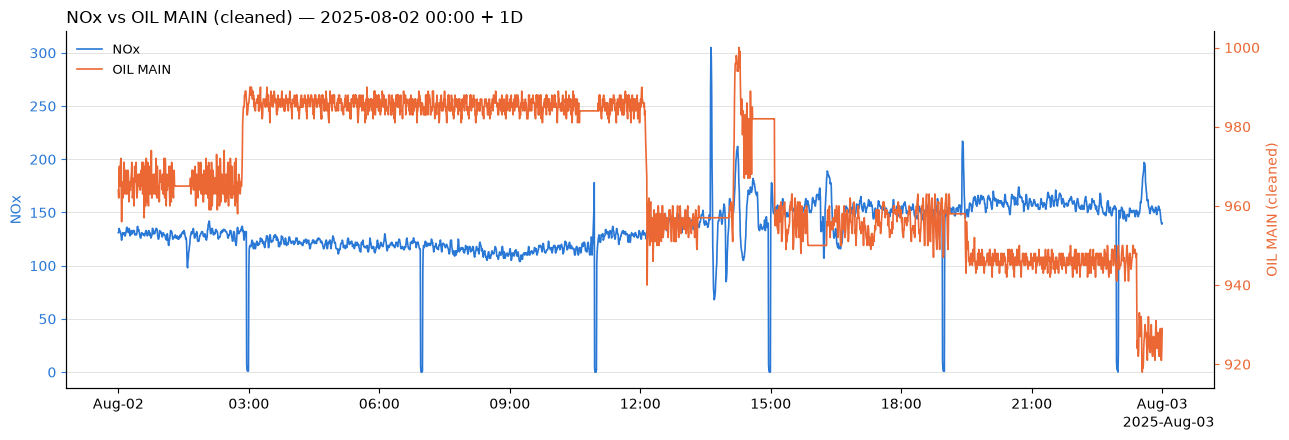

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ---- config ---------------------------------------------------------------
WIN_START = "2025-08-02 00:00"
WIN_LEN   = "1D"          # must be >= 1 day
TWIN      = True          # True = shared x, two y-axes; False = stacked panels
THIN      = None          # None = every raw point; or e.g. "5min" -> mean resample

SAVE     = True
SAVE_DIR = Path("plots")
DPI      = 150

NOX_C, OIL_C = "#2a78d6", "#eb6834"
# ---------------------------------------------------------------------------

assert pd.Timedelta(WIN_LEN) >= pd.Timedelta("1D"), f"WIN_LEN must be >= 1D, got {WIN_LEN}"
plt.rcParams["path.simplify"] = False

OIL_MAIN = "OIL MAIN_cleaned"
if OIL_MAIN not in df.columns:                      # pull it in once, aligned to df
    _m = pd.read_parquet(DATA, columns=["Date", OIL_MAIN])
    _m["Date"] = pd.to_datetime(_m["Date"])
    _m = _m.set_index("Date").sort_index()
    df[OIL_MAIN] = _m[OIL_MAIN].reindex(df.index)
    df[OIL_MAIN] = df[OIL_MAIN].where(df[OIL_MAIN] > 0)   # weird -> NaN, as before

t0 = pd.Timestamp(WIN_START)
t1 = t0 + pd.Timedelta(WIN_LEN)
w = df.loc[t0:t1, [TARGET, OIL_MAIN]]
if THIN:
    w = w.resample(THIN).mean()
print(f"{t0} -> {t1} | {len(w)} points{' | thinned ' + THIN if THIN else ''}")

title = f"NOx vs OIL MAIN (cleaned) — {t0:%Y-%m-%d %H:%M} + {WIN_LEN}"

if TWIN:
    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax2 = ax.twinx()
    l1, = ax.plot(w.index, w[TARGET], lw=1.2, color=NOX_C, label="NOx")
    l2, = ax2.plot(w.index, w[OIL_MAIN], lw=1.2, color=OIL_C, label="OIL MAIN")
    ax.set_ylabel("NOx", color=NOX_C)
    ax2.set_ylabel("OIL MAIN (cleaned)", color=OIL_C)
    ax.tick_params(axis="y", colors=NOX_C)
    ax2.tick_params(axis="y", colors=OIL_C)
    ax.legend(handles=[l1, l2], frameon=False, loc="upper left", fontsize=9)
    ax.set_title(title, loc="left")
    axes = [ax]
    ax2.spines["top"].set_visible(False)
else:
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    axes[0].plot(w.index, w[TARGET], lw=1.2, color=NOX_C)
    axes[0].set_ylabel("NOx")
    axes[0].set_title(title, loc="left")
    axes[1].plot(w.index, w[OIL_MAIN], lw=1.2, color=OIL_C)
    axes[1].set_ylabel("OIL MAIN (cleaned)")
    axes = list(axes)

for a in axes:
    a.grid(axis="y", lw=0.5, color="#d8d8d4")
    for s in ("top", "right" if not TWIN else "top"):
        a.spines[s].set_visible(False)

axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
fig.tight_layout()

if SAVE:
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    fname = f"nox_oilmain_{t0:%Y%m%d_%H%M}_{WIN_LEN}{'_twin' if TWIN else ''}.png"
    fig.savefig(SAVE_DIR / fname, dpi=DPI, bbox_inches="tight", facecolor="white")
    print("saved ->", SAVE_DIR / fname)

plt.show()
